In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 25)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='Set2')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': pct}).to_string())

=== Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Missing Values ===
                  Missing Count  Missing %
customerID                    0        0.0
gender                        0        0.0
SeniorCitizen                 0        0.0
Partner                       0        0.0
Dependents                    0        0.0
tenure                        0        0.0
PhoneService                  0        0.0
MultipleLin

In [4]:
# Fix TotalCharges - convert to numeric (blank spaces become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many became NaN
print(f"TotalCharges missing after conversion: {df['TotalCharges'].isnull().sum()}")

# Fill those NaN with 0 (new customers with no charges yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Convert SeniorCitizen from 0/1 to Yes/No
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Convert Churn to binary for calculations
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Cleaning complete!")
print(f"Churn rate: {df['Churn_Binary'].mean()*100:.1f}%")

TotalCharges missing after conversion: 11
Cleaning complete!
Churn rate: 26.5%


In [5]:
print("=== Numerical Summary ===")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))
print()
print("=== Churn Distribution ===")
print(df['Churn'].value_counts())
print()
print("=== Contract Type Distribution ===")
print(df['Contract'].value_counts())
print()
print("=== Internet Service Distribution ===")
print(df['InternetService'].value_counts())

=== Numerical Summary ===
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80

=== Churn Distribution ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

=== Contract Type Distribution ===
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

=== Internet Service Distribution ===
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


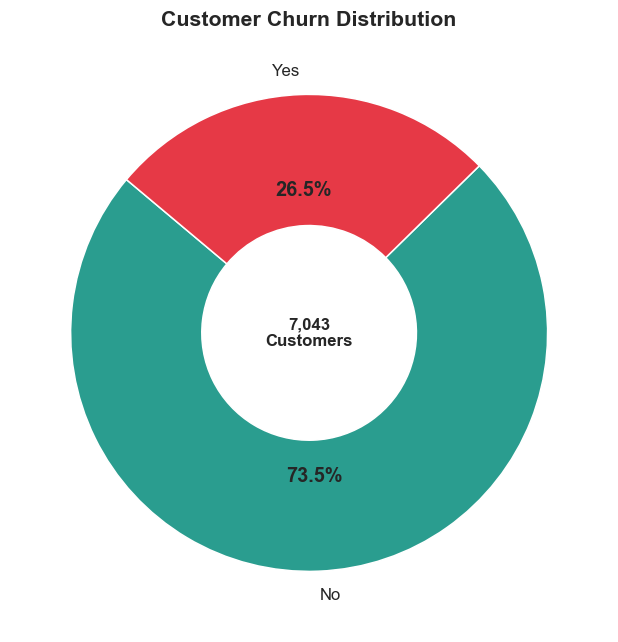

Finding: 26.5% of customers churned — 1 in 4 customers is leaving.


In [6]:
# ── Fig 1: Churn Distribution (Donut Chart) ──────────────────────────────
churn_counts = df['Churn'].value_counts()

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#2a9d8f', '#e63946']
wedges, texts, autotexts = ax.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.55))
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
centre = plt.Circle((0, 0), 0.35, fc='white')
ax.add_patch(centre)
ax.text(0, 0, f'{len(df):,}\nCustomers', ha='center', va='center',
        fontsize=11, fontweight='bold')
ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_churn_distribution.png', bbox_inches='tight')
plt.show()
print("Finding: 26.5% of customers churned — 1 in 4 customers is leaving.")

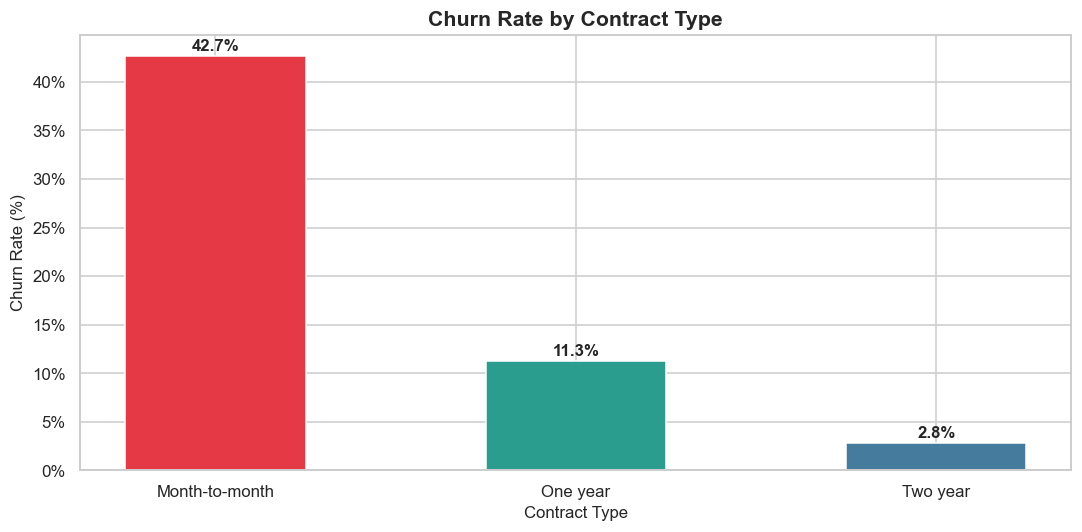

Finding: Month-to-month customers churn at a dramatically higher rate.


In [8]:
# ── Fig 2: Churn by Contract Type (Bar Chart) ────────────────────────────
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e63946', '#2a9d8f', '#457b9d']
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Contract Type', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('fig2_churn_by_contract.png', bbox_inches='tight')
plt.show()
print("Finding: Month-to-month customers churn at a dramatically higher rate.")

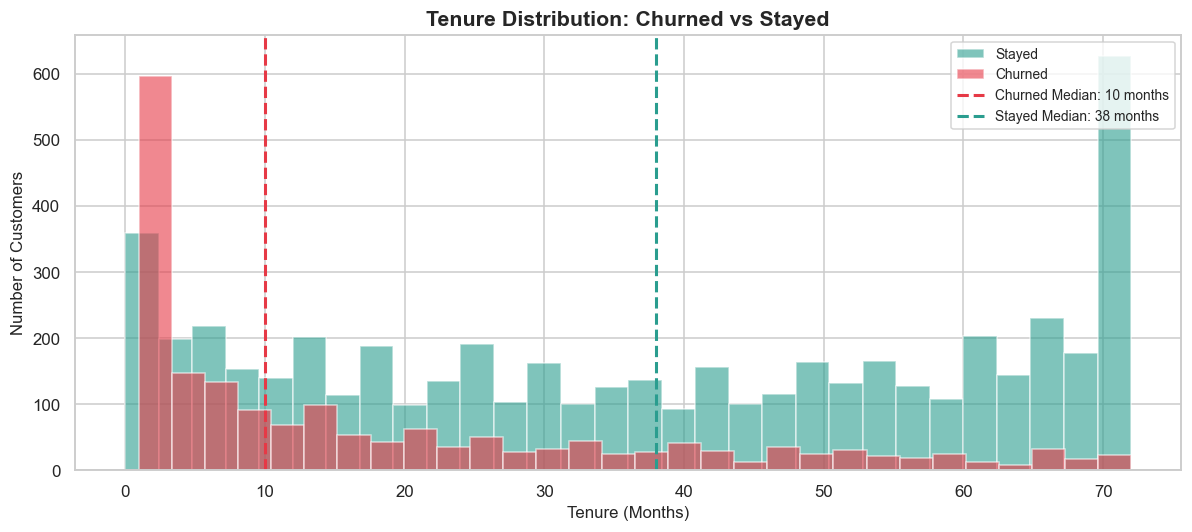

Finding: Churned customers median tenure: 10 months
         Stayed customers median tenure : 38 months


In [9]:
# ── Fig 3: Churn by Tenure (Histogram) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

churned = df[df['Churn'] == 'Yes']['tenure']
stayed = df[df['Churn'] == 'No']['tenure']

ax.hist(stayed, bins=30, alpha=0.6, color='#2a9d8f', label='Stayed')
ax.hist(churned, bins=30, alpha=0.6, color='#e63946', label='Churned')

ax.set_xlabel('Tenure (Months)', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_title('Tenure Distribution: Churned vs Stayed', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axvline(churned.median(), color='#e63946', lw=2, ls='--',
           label=f'Churned Median: {churned.median():.0f} months')
ax.axvline(stayed.median(), color='#2a9d8f', lw=2, ls='--',
           label=f'Stayed Median: {stayed.median():.0f} months')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig3_tenure_distribution.png', bbox_inches='tight')
plt.show()
print(f"Finding: Churned customers median tenure: {churned.median():.0f} months")
print(f"         Stayed customers median tenure : {stayed.median():.0f} months")

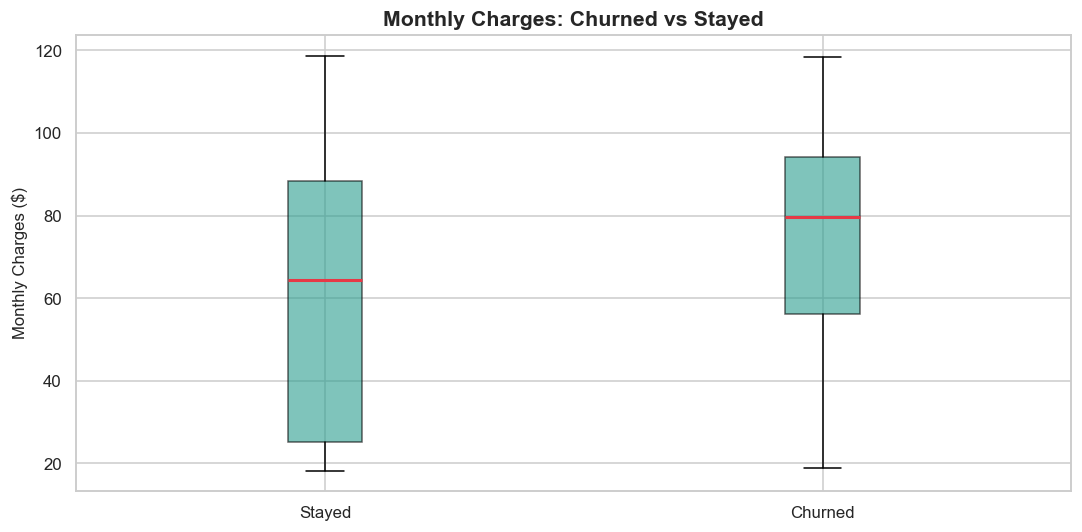

Finding: Churned customers avg monthly charge: $74.44
         Stayed customers avg monthly charge : $61.27


In [10]:
# ── Fig 4: Churn by Monthly Charges (Box Plot) ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

churned_charges = df[df['Churn'] == 'Yes']['MonthlyCharges']
stayed_charges  = df[df['Churn'] == 'No']['MonthlyCharges']

ax.boxplot([stayed_charges, churned_charges],
           labels=['Stayed', 'Churned'],
           patch_artist=True,
           boxprops=dict(facecolor='#2a9d8f', alpha=0.6),
           medianprops=dict(color='#e63946', lw=2))

ax.set_ylabel('Monthly Charges ($)', fontsize=11)
ax.set_title('Monthly Charges: Churned vs Stayed', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_monthly_charges_boxplot.png', bbox_inches='tight')
plt.show()
print(f"Finding: Churned customers avg monthly charge: ${churned_charges.mean():.2f}")
print(f"         Stayed customers avg monthly charge : ${stayed_charges.mean():.2f}")

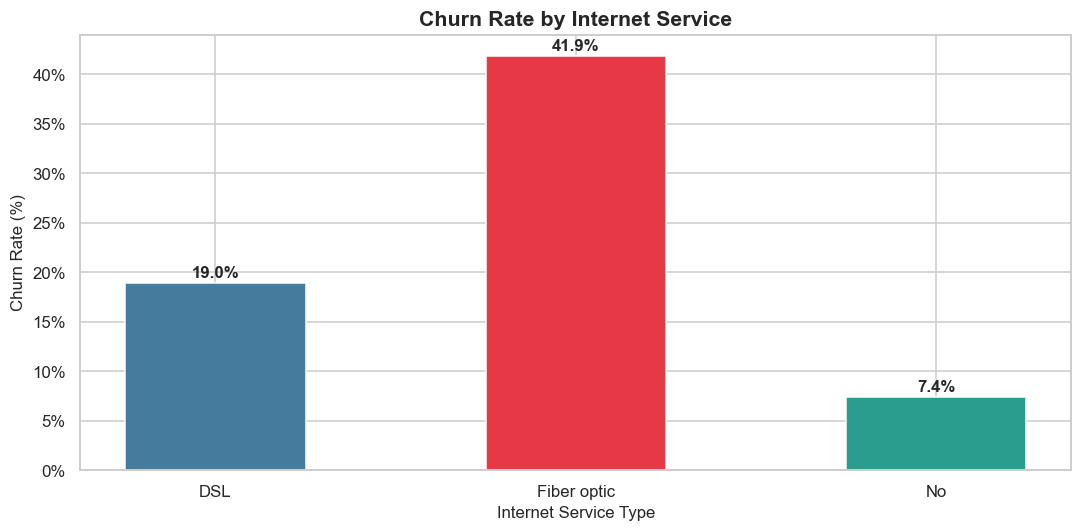

Finding: Fiber optic customers churn at the highest rate.


In [11]:
# ── Fig 5: Churn by Internet Service (Bar Chart) ─────────────────────────
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#457b9d', '#e63946', '#2a9d8f']
bars = ax.bar(internet_churn.index, internet_churn.values,
              color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, internet_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Internet Service Type', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('fig5_churn_by_internet.png', bbox_inches='tight')
plt.show()
print("Finding: Fiber optic customers churn at the highest rate.")

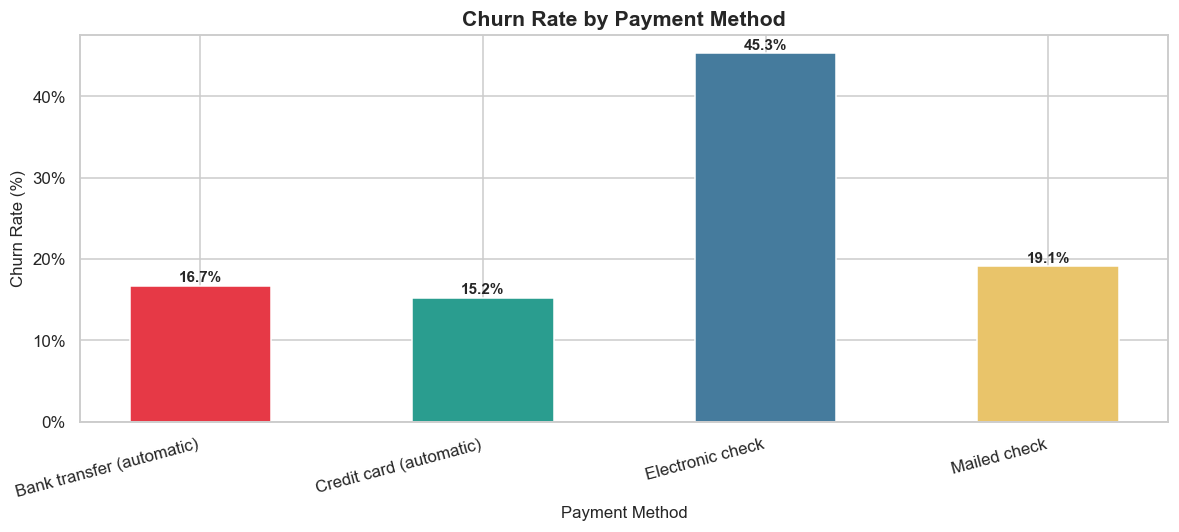

Finding: Electronic check customers churn at the highest rate.


In [12]:
# ── Fig 6: Churn by Payment Method (Bar Chart) ───────────────────────────
payment_churn = df.groupby('PaymentMethod')['Churn_Binary'].mean() * 100

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#e63946', '#2a9d8f', '#457b9d', '#e9c46a']
bars = ax.bar(payment_churn.index, payment_churn.values,
              color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, payment_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Payment Method', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('fig6_churn_by_payment.png', bbox_inches='tight')
plt.show()
print("Finding: Electronic check customers churn at the highest rate.")

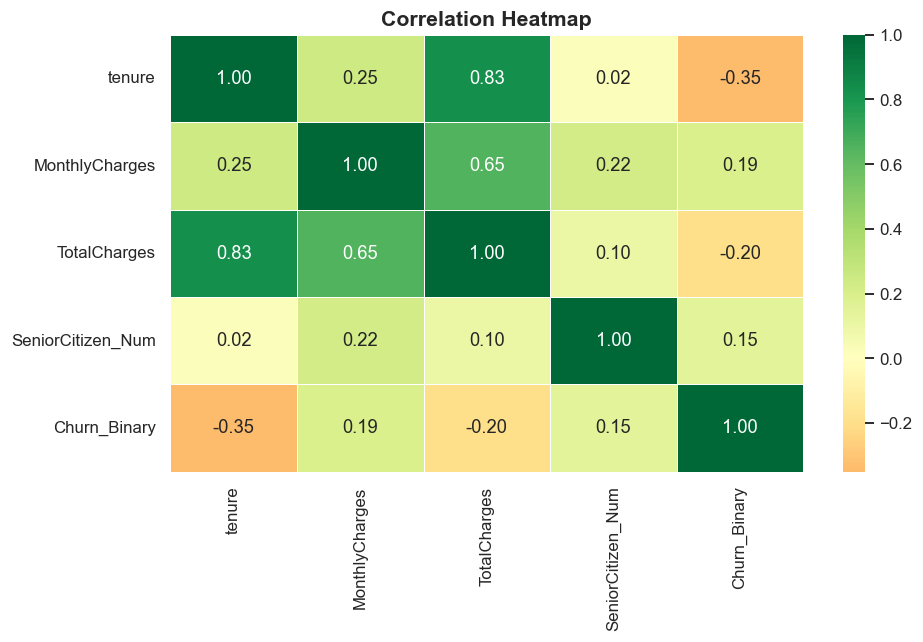

Finding: Tenure has the strongest negative correlation with churn.
         Monthly charges has a positive correlation with churn.


In [13]:
# ── Fig 7: Correlation Heatmap ───────────────────────────────────────────
# Select numerical columns plus churn binary
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary',
             'SeniorCitizen']
df['SeniorCitizen_Num'] = df['SeniorCitizen'].map({'Yes': 1, 'No': 0})
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
             'SeniorCitizen_Num', 'Churn_Binary']

corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Finding: Tenure has the strongest negative correlation with churn.")
print("         Monthly charges has a positive correlation with churn.")

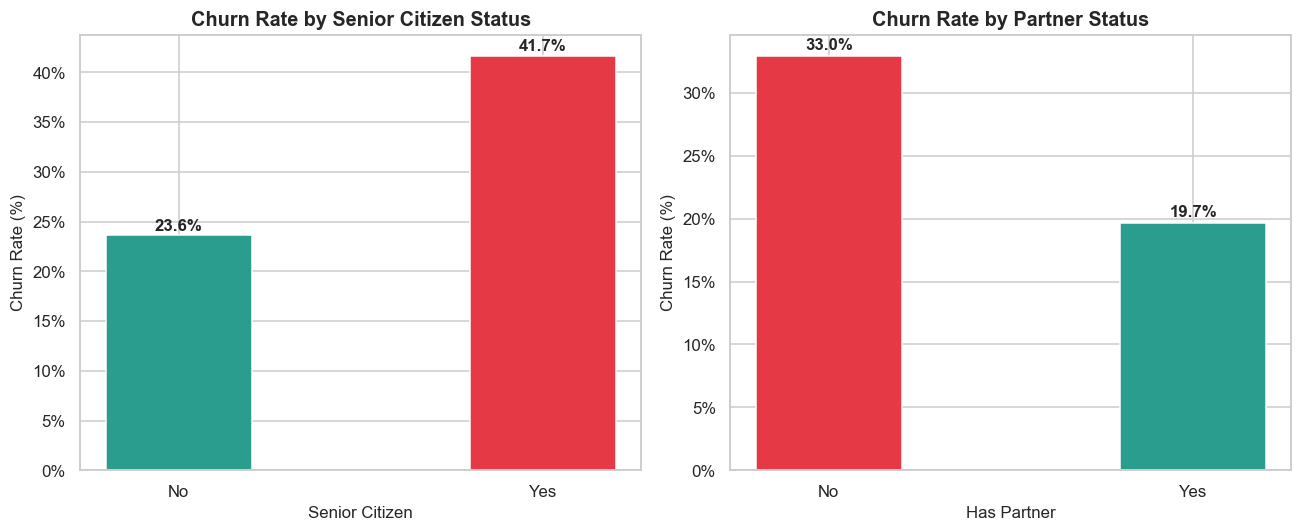

Finding: Senior citizens and customers without partners churn more.


In [14]:
# ── Fig 8: Churn by Senior Citizen & Partner Status ──────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Senior Citizen
senior_churn = df.groupby('SeniorCitizen')['Churn_Binary'].mean() * 100
colors = ['#2a9d8f', '#e63946']
ax1.bar(senior_churn.index, senior_churn.values,
        color=colors, edgecolor='white', width=0.4)
for i, val in enumerate(senior_churn.values):
    ax1.text(i, val + 0.5, f'{val:.1f}%', ha='center',
             fontsize=11, fontweight='bold')
ax1.set_xlabel('Senior Citizen', fontsize=11)
ax1.set_ylabel('Churn Rate (%)', fontsize=11)
ax1.set_title('Churn Rate by Senior Citizen Status',
              fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Partner Status
partner_churn = df.groupby('Partner')['Churn_Binary'].mean() * 100
ax2.bar(partner_churn.index, partner_churn.values,
        color=['#e63946', '#2a9d8f'], edgecolor='white', width=0.4)
for i, val in enumerate(partner_churn.values):
    ax2.text(i, val + 0.5, f'{val:.1f}%', ha='center',
             fontsize=11, fontweight='bold')
ax2.set_xlabel('Has Partner', fontsize=11)
ax2.set_ylabel('Churn Rate (%)', fontsize=11)
ax2.set_title('Churn Rate by Partner Status',
              fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('fig8_senior_partner_churn.png', bbox_inches='tight')
plt.show()
print("Finding: Senior citizens and customers without partners churn more.")

In [16]:
# Save cleaned dataset for Power BI
df.to_csv('telco_churn_clean.csv', index=False)
print(f"✅ Saved telco_churn_clean.csv ({len(df):,} rows)")

# Print key summary for report
print()
print("=== KEY METRICS FOR REPORT ===")
print(f"Total Customers       : {len(df):,}")
print(f"Churned Customers     : {df['Churn_Binary'].sum():,}")
print(f"Overall Churn Rate    : {df['Churn_Binary'].mean()*100:.1f}%")
print(f"Avg Monthly Charges   : ${df['MonthlyCharges'].mean():.2f}")
print(f"Avg Tenure            : {df['tenure'].mean():.1f} months")
print(f"Month-to-Month %      : {(df['Contract']=='Month-to-month').mean()*100:.1f}%")
print(f"Fiber Optic Churn Rate: {df[df['InternetService']=='Fiber optic']['Churn_Binary'].mean()*100:.1f}%")
print(f"Month-to-Month Churn  : {df[df['Contract']=='Month-to-month']['Churn_Binary'].mean()*100:.1f}%")

✅ Saved telco_churn_clean.csv (7,043 rows)

=== KEY METRICS FOR REPORT ===
Total Customers       : 7,043
Churned Customers     : 1,869
Overall Churn Rate    : 26.5%
Avg Monthly Charges   : $64.76
Avg Tenure            : 32.4 months
Month-to-Month %      : 55.0%
Fiber Optic Churn Rate: 41.9%
Month-to-Month Churn  : 42.7%
